# 🧠 Project: Impact of Short-Term Rentals on the Housing Market
This notebook is part of Phase 2 of the project for the course Information Integration and Analytic Processing.

📌 Objectives:
- Integrate data from multiple sources.
- Analyze the relationship between short-term rental density, population, and rental prices.
- Implement data cleaning, schema integration, and identity resolution techniques.

---

## 1.📦 Data Acquisition

### 1.1 Dataset Overview

In this section, we import the different datasets required to analyze the impact of short-term rentals on urban areas in Portugal. Each dataset comes from a distinct source and provides a specific perspective on urban characteristics, such as population density, rental supply, housing prices, and administrative divisions.

The datasets imported are as follows:

- **`portugal_listings.csv`**: Contains information about properties available for purchase across the country, including fields like `Price`, `District`, `City`, and `Town`.  
  **Source**: https://www.kaggle.com/datasets/luvathoms/portugal-real-estate-2024

- **`rendasm2.json`**: Provides average rental prices per square meter for different regions in **2023**.  
  **Source**: https://www.ine.pt/bddXplorer/htdocs/minfo.jsp?var_cd=0012600&lingua=PT

- **`densidadePopulacional.json`**: Indicates population density (inhabitants/km²) by municipality for **2023**.  
  **Source**: https://www.ine.pt/bddXplorer/htdocs/minfo.jsp?var_cd=0008337&lingua=PT

- **`densidadealojamentosm2.json`**: Presents the density of short-term rental units (units/km²) at the **parish level**, for **2021**.  
  **Source**: https://www.ine.pt/bddXplorer/htdocs/minfo.jsp?var_cd=0012514&lingua=PT

- **`Areas_Freg_Conc_Dist_Pais_CAOP2019.xls`**: The CAOP (Carta Administrativa Oficial de Portugal) file defines the country’s administrative structure, including districts, municipalities, and parishes. It is used as a reference to unify geographic codes (`DICO`, `geocod`, etc.).  
  **Source**: https://www.dgterritorio.gov.pt/cartografia/cartografia-tematica/caop

> ⚠️ Each file was loaded based on its internal structure (`.csv`, `.json`, `.xls`) and only the relevant content was extracted for further cleaning and integration.

### 1.2 Code

In [472]:
import pandas as pd

# Load dataset with property listings available for sale
property_listings = pd.read_csv(r'dados\portugal_listings.csv')

# Load dataset with average rental prices per square meter for 2023
rental_prices_raw = pd.read_json(r'dados\rendasm2.json')
rental_prices = pd.DataFrame(rental_prices_raw['Dados'][0]['2023'])

# Load dataset with population density (inhabitants/km²) by municipality for 2023
population_density_raw = pd.read_json(r'dados\densidadePopulacional.json')
population_density = pd.DataFrame(population_density_raw['Dados'][0]['2023'])

# Load dataset with short-term rental density (units/km²) by parish for 2021
short_term_rental_density_raw = pd.read_json(r'dados\densidadealojamentosm2.json')
short_term_rental_density = pd.DataFrame(short_term_rental_density_raw['Dados'][0]['2021'])

# Load reference table with official administrative boundaries (CAOP)
municipalities = pd.read_excel(r'dados\Areas_Freg_Conc_Dist_Pais_CAOP2019.xls',
                               sheet_name='Areas_Concelhos_CAOP2019')


All datasets are now successfully loaded into memory and stored in well-labeled variables.  
In the next section, we will perform data profiling and initial integration in order to understand their structure and prepare for cleaning and transformation.

---

## 2. 🔍 Data Profiling

### 2.1 Overview

After importing the data, an exploratory analysis (*data profiling*) was conducted to understand the structure and quality of each dataset. This included:

- Data type identification  
- Counting and percentage of missing values  
- Number of unique values per column (*cardinality*)

A custom function was used to display these metrics for each dataset.

In [473]:
def data_profiling(df: pd.DataFrame):
    profiling = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.values,
        "Non-Null Count": df.notnull().sum().values,
        "Null Count": df.isnull().sum().values,
        "% Nulls": (df.isnull().mean() * 100).round(2).values,
        "Unique Values": df.nunique().values
    })
    display(profiling)

### 2.2 Profiling by Dataset

#### 2.2.1 Administrative Boundaries (`municipalities`)

- **Granularity**: Municipality-level  
- **Relevant columns**:
  - `DICO`: unique identifier → used as `MunicipalityCode`
  - `CONCELHO_DSG`: municipality name
  - `NUTSIII_DSG`: NUTS III region

- Ignored columns:
  - Other NUTS codes, area, perimeter, altitude

##### Sample and Distribution (municipalities)

We preview a sample of the main fields and review value distributions to understand structure and consistency.

In [474]:
# Profiling original
data_profiling(municipalities)

# Preview: random sample
print("Sample: municipalities")
display(municipalities.sample(5, random_state=10))

# Summary of unique values
print("Number of unique municipalities:", municipalities["CONCELHO_DSG"].value_counts().sum())
print("Number of unique regions (NUTSIII):", municipalities["NUTSIII_DSG"].nunique())

# Most common values
print("\nTop 5 most common municipalities:")
display(municipalities["CONCELHO_DSG"].value_counts().head(5))

print("\nTop 5 most common regions:")
display(municipalities["NUTSIII_DSG"].value_counts().head(5))


,Column,Data Type,Non-Null Count,Null Count,% Nulls,Unique Values
0,DICO,int64,308,0,0.0,308
1,NUTSI_DSG,object,308,0,0.0,3
2,NUTSI_COD,int64,308,0,0.0,3
3,NUTSII_DSG,object,308,0,0.0,7
4,NUTSII_COD,int64,308,0,0.0,7
5,NUTSIII_DSG,object,308,0,0.0,25
6,NUTSIII_COD,object,308,0,0.0,25
7,DISTRITO_ILHA_DSG,object,308,0,0.0,29
8,CONCELHO_DSG,object,308,0,0.0,307
9,AREA_2019_ha,float64,308,0,0.0,308


Sample: municipalities


,DICO,NUTSI_DSG,NUTSI_COD,NUTSII_DSG,NUTSII_COD,NUTSIII_DSG,NUTSIII_COD,DISTRITO_ILHA_DSG,CONCELHO_DSG,AREA_2019_ha,AREA_2019_km2,PERIM_km,ALTITUDE_MAX_m,ALTITUDE_MIN_m
111,811,CONTINENTE,1,ALGARVE,15,ALGARVE,150,FARO,PORTIMÃO,18206.29,182.06,83,325,0
283,3106,REGIÃO AUTÓNOMA DA MADEIRA,3,REGIÃO AUTÓNOMA DA MADEIRA,30,REGIÃO AUTÓNOMA DA MADEIRA,300,ILHA DA MADEIRA,PORTO MONIZ,8293.38,82.93,57,1640,0
238,1609,CONTINENTE,1,NORTE,11,ALTO MINHO,111,VIANA DO CASTELO,VIANA DO CASTELO,31902.01,319.02,98,823,0
127,911,CONTINENTE,1,CENTRO,16,BEIRAS E SERRA DA ESTRELA,16J,GUARDA,SABUGAL,82269.82,822.70,182,1223,450
189,1312,CONTINENTE,1,NORTE,11,ÁREA METROPOLITANA DO PORTO,11A,PORTO,PORTO,4142.02,41.42,36,157,0


Number of unique municipalities: 308
Number of unique regions (NUTSIII): 25

Top 5 most common municipalities:


CONCELHO_DSG
LAGOA                 2
ANADIA                1
VILA NOVA DE PAIVA    1
VALE DE CAMBRA        1
ÁGUEDA                1
Name: count, dtype: int64


Top 5 most common regions:


NUTSIII_DSG
REGIÃO DE COIMBRA               19
REGIÃO AUTÓNOMA DOS AÇORES      19
DOURO                           19
ÁREA METROPOLITANA DE LISBOA    18
ÁREA METROPOLITANA DO PORTO     17
Name: count, dtype: int64

#### 2.2.2 Short-Term Rental Density (`short_term_rental_density`)

- **Granularity**: Parish-level (freguesia)  
- **Relevant columns**:
  - `geocod`: used to derive `MunicipalityCode` (first 4 digits)
  - `geodsg`: parish name → used to infer `Municipality`
  - `valor`: indicator value → converted to float

- Ignored columns:
  - `ind_string`

##### Sample and Distribution (short_term_rental_density)

We explore examples and the distribution of STR density per parish to detect possible outliers and regional concentration.

In [475]:
data_profiling(short_term_rental_density)

print("Sample: short_term_rental_density")
display(short_term_rental_density[["geodsg", "valor"]].sample(5, random_state=11))

print("Number of unique parishes:", short_term_rental_density["geodsg"].nunique())

print("Top 5 parishes with most entries:")
display(short_term_rental_density["geodsg"].value_counts().head(5))

print("Distribution of STR density (valor):")
display(short_term_rental_density["valor"].describe())

,Column,Data Type,Non-Null Count,Null Count,% Nulls,Unique Values
0,geocod,object,3439,0,0.0,3439
1,geodsg,object,3439,0,0.0,3075
2,ind_string,object,3439,0,0.0,1656
3,valor,object,3439,0,0.0,1656


Sample: short_term_rental_density


,geodsg,valor
1965,Geraz do Minho,57
1687,Fontes,45
1839,Praia do Ribatejo,52.1
1596,Oliveira de Frades,41.2
2833,União das freguesias de Trouxemil e Torre de V...,167.3


Number of unique parishes: 3075
Top 5 parishes with most entries:


geodsg
Pinheiro          6
Santana           5
Santa Bárbara     5
Carvalhal         5
Rio de Moinhos    5
Name: count, dtype: int64

Distribution of STR density (valor):


count     3439
unique    1656
top        8.7
freq        15
Name: valor, dtype: object

#### 2.2.3 Population Density (`population_density`)

- **Granularity**: Municipality-level  
- **Relevant columns**:
  - `geocod`: used to derive `MunicipalityCode` (last 4 digits)
  - `geodsg`: municipality name
  - `valor`: population density → converted to float

- Ignored columns:
  - `ind_string`

##### Sample and Distribution (population_density)

We check population values to understand variability across regions and potential inconsistencies.

In [476]:
data_profiling(population_density)

print("Sample: population_density")
display(population_density[["geodsg", "valor"]].sample(5, random_state=12))

print("Number of unique municipalities:", population_density["geodsg"].nunique())

print("Top 5 municipalities with most entries:")
display(population_density["geodsg"].value_counts().head(5))

print("Distribution of population density (valor):")
display(population_density["valor"].describe())

,Column,Data Type,Non-Null Count,Null Count,% Nulls,Unique Values
0,geocod,object,347,0,0.0,347
1,geodsg,object,347,0,0.0,340
2,ind_string,object,347,0,0.0,316
3,valor,object,347,0,0.0,316


Sample: population_density


,geodsg,valor
78,Trancoso,23
106,Mirandela,32.5
210,Região Autónoma dos Açores,103.8
131,Borba,44.1
307,Península de Setúbal,513.5


Number of unique municipalities: 340
Top 5 municipalities with most entries:


geodsg
Região Autónoma dos Açores    3
Região Autónoma da Madeira    3
Grande Lisboa                 2
Algarve                       2
Península de Setúbal          2
Name: count, dtype: int64

Distribution of population density (valor):


count     347
unique    316
top        16
freq        3
Name: valor, dtype: object

#### 2.2.4 Property Listings (`property_listings`)

- **Granularity**: Municipality-level (inferred from city names)  
- **Relevant columns**:
  - `Price`: property sale price
  - `District`: administrative district
  - `City`: municipality inferred from city name

- Ignored columns:
  - `Town`
  - All columns starting with `Unnamed:` (present due to CSV formatting)

##### Sample and Distribution (property_listings)

We preview real estate records and analyze price distributions for potential anomalies or extreme values.

In [477]:
data_profiling(property_listings)

print("Sample: property_listings")
display(property_listings[["Price", "District", "City"]].sample(5, random_state=13))

print("Number of unique districts:", property_listings["District"].nunique())
print("Number of unique cities:", property_listings["City"].nunique())

print("Top 5 cities with most listings:")
display(property_listings["City"].value_counts().head(5))

print("Top 5 districts with most listings:")
display(property_listings["District"].value_counts().head(5))

print("Distribution of property prices:")
display(property_listings["Price"].describe())

print("Cities with only one listing (possible anomalies):")
display(property_listings["City"].value_counts().tail(10))

# Lista de distritos únicos (ordenada)
unique_districts = sorted(property_listings["District"].dropna().unique())
print(f"✅ Total unique districts: {len(unique_districts)}")
for district in unique_districts:
    print("-", district)




,Column,Data Type,Non-Null Count,Null Count,% Nulls,Unique Values
0,Price,float64,135236,300,0.22,4754
1,District,object,135536,0,0.00,27
2,City,object,135536,0,0.00,275
3,Town,object,135534,2,0.00,2263
4,Unnamed: 4,float64,0,135536,100.00,0
5,Unnamed: 5,float64,0,135536,100.00,0
6,Unnamed: 6,float64,0,135536,100.00,0
7,Unnamed: 7,float64,0,135536,100.00,0
8,Unnamed: 8,float64,0,135536,100.00,0
9,Unnamed: 9,float64,0,135536,100.00,0


Sample: property_listings


,Price,District,City
46734,515000.0,Porto,Vila Nova de Gaia
103753,70000.0,Porto,Penafiel
64414,219000.0,Porto,Vila Nova de Gaia
2260,1299000.0,Faro,Portimão
6895,96500.0,Lisboa,Sintra


Number of unique districts: 27
Number of unique cities: 275
Top 5 cities with most listings:


City
Lisboa               8396
Sintra               5527
Porto                5446
Vila Nova de Gaia    4281
Cascais              3236
Name: count, dtype: int64

...

Distribution of property prices:


count    1.352360e+05
mean     3.681374e+05
std      3.804044e+06
min      1.000000e+00
25%      8.400000e+04
50%      2.100000e+05
75%      3.950000e+05
max      1.380000e+09
Name: Price, dtype: float64

Cities with only one listing (possible anomalies):


City
Machico                  5
Castro Daire             4
Santa Cruz               2
Penedono                 2
Mortágua                 1
Funchal                  1
Velas                    1
Cinfães                  1
Horta                    1
Santa Cruz das Flores    1
Name: count, dtype: int64

✅ Total unique districts: 27
- Aveiro
- Beja
- Braga
- Bragança
- Castelo Branco
- Coimbra
- Faro
- Guarda
- Ilha Terceira
- Ilha da Madeira
- Ilha das Flores
- Ilha de Porto Santo
- Ilha de Santa Maria
- Ilha de São Jorge
- Ilha de São Miguel
- Ilha do Faial
- Leiria
- Lisboa
- Portalegre
- Porto
- Santarém
- Setúbal
- Viana do Castelo
- Vila Real
- Viseu
- Z - Fora de Portugal
- Évora


#### Price Range Distribution

To better understand the distribution of property prices, we grouped all listings into manually defined price ranges.

The chart below shows the number of listings in each range, highlighting the concentration around €100K–300K, and confirming the presence of a long tail with high-value properties.


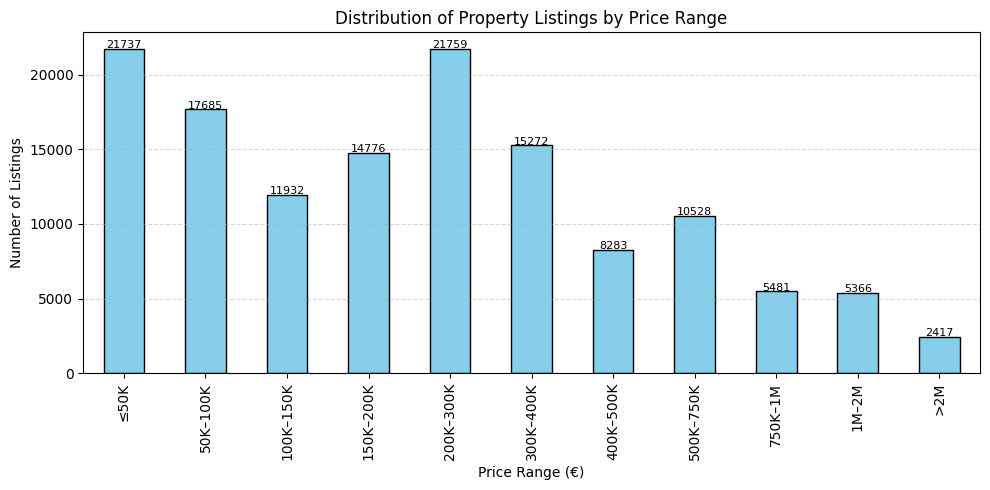

In [478]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Definir bins e labels (não alterar o dataframe original)
price_bins = [0, 50_000, 100_000, 150_000, 200_000, 300_000, 400_000, 500_000, 750_000, 1_000_000, 2_000_000, np.inf]
labels = [
    "≤50K", "50K–100K", "100K–150K", "150K–200K", "200K–300K",
    "300K–400K", "400K–500K", "500K–750K", "750K–1M", "1M–2M", ">2M"
]

# Garantir tipo numérico (sem alterar o original se já estiver tratado)
prices_temp = pd.to_numeric(property_listings["Price"], errors="coerce")

# Criar coluna temporária com faixas
price_range_temp = pd.cut(prices_temp, bins=price_bins, labels=labels)

# Contagem por faixa
price_range_counts = price_range_temp.value_counts().reindex(labels)

# Gráfico de barras
plt.figure(figsize=(10, 5))
ax = price_range_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Distribution of Property Listings by Price Range")
plt.xlabel("Price Range (€)")
plt.ylabel("Number of Listings")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Adicionar os valores acima de cada barra
for i, v in enumerate(price_range_counts):
    plt.text(i, v + 50, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()


##### Observations on Property Price Distribution
- The majority of listings fall within the **€100,000 to €300,000** range, with a peak in the **€200K–300K** interval.
- There is a notable concentration of properties priced between **€50K and €150K**, reflecting activity in the lower-middle market.
- **Listings below €50,000** (~1,000 records) are likely unrealistic:
  - Possible input errors or missing digits  
  - Placeholder values or test data
  - Non-residential listings mislabeled
- A long tail of **high-value properties** exists, with more than **13,000 listings above €750K**, which may include:
  - Luxury real estate  
  - Inconsistent or outlier entries

#### 2.2.5 Rental Prices (`rental_prices`)

- **Granularity**: Parish-level (freguesia)  
- **Relevant columns**:
  - `geocod`: used to derive `MunicipalityCode` (last 4 digits)
  - `geodsg`: name used as `Municipality`
  - `valor`: average rent → converted to float

- Ignored columns:
  - `ind_string`, `sinal_conv`, `sinal_conv_desc`

##### Sample and Distribution (rental_prices)

This shows sample rent values and their distribution across parishes. May help detect extremely low or high values, or missing units.

In [479]:
data_profiling(rental_prices)

print("Sample: rental_prices")
display(rental_prices[["geodsg", "valor"]].sample(5, random_state=14))

print("Number of unique parish names:", rental_prices["geodsg"].nunique())

print("Top 5 most common entries:")
display(rental_prices["geodsg"].value_counts().head(5))

print("Distribution of rental prices per m² (valor):")
display(rental_prices["valor"].describe())

,Column,Data Type,Non-Null Count,Null Count,% Nulls,Unique Values
0,geocod,object,638,0,0.00,638
1,geodsg,object,638,0,0.00,616
2,ind_string,object,638,0,0.00,343
3,valor,object,431,207,32.45,341
4,sinal_conv,object,207,431,67.55,2
5,sinal_conv_desc,object,207,431,67.55,2


Sample: rental_prices


,geodsg,valor
198,Ovar,5.76
117,Ave,4.61
58,Douro,3.77
405,Olivais,13.79
465,Junqueira,NaN


Number of unique parish names: 616
Top 5 most common entries:


geodsg
Região Autónoma da Madeira    3
Região Autónoma dos Açores    3
Algarve                       2
Espinho                       2
Palmela                       2
Name: count, dtype: int64

Distribution of rental prices per m² (valor):


count      431
unique     341
top       5.08
freq         5
Name: valor, dtype: object

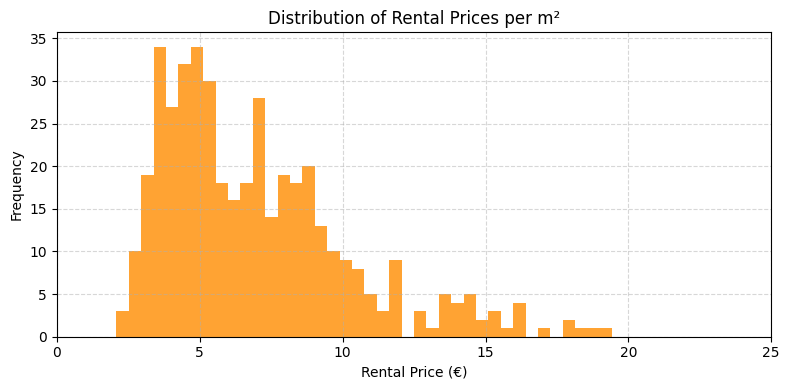

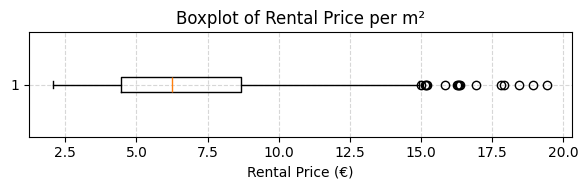

In [480]:
# Garantir tipo numérico
rental_prices["valor"] = pd.to_numeric(rental_prices["valor"], errors="coerce")

# Histograma
plt.figure(figsize=(8, 4))
plt.hist(rental_prices["valor"].dropna(), bins=40, color="darkorange", alpha=0.8)
plt.title("Distribution of Rental Prices per m²")
plt.xlabel("Rental Price (€)")
plt.ylabel("Frequency")
plt.xlim(0, 25)  # Limite visual — ajusta com base nos teus dados
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(6, 2))
plt.boxplot(rental_prices["valor"].dropna(), vert=False)
plt.title("Boxplot of Rental Price per m²")
plt.xlabel("Rental Price (€)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


##### Observations
- Most rental prices per square meter fall between 4€ and 10€, with a median around 6–7€.
- The distribution is skewed to the right, indicating that a small number of parishes have significantly higher rents.
- Outliers above 15€/m² may represent urban centers or premium real estate and should be handled carefully in downstream analysis.


### 2.3 Key Identifiers Summary

| Dataset                    | Primary Key                             | Other Relevant Columns                      |
|----------------------------|------------------------------------------|---------------------------------------------|
| `municipalities`           | `DICO` → `MunicipalityCode`             | `CONCELHO_DSG` → `Municipality`, `NUTSIII_DSG` → `Region` |
| `population_density`       | `geocod[-4:]` → `MunicipalityCode`      | `geodsg` → `Municipality`                   |
| `short_term_rental_density`| `geocod[:4]` → `MunicipalityCode`       | `geodsg` → `Municipality`                   |
| `rental_prices`            | `geocod[-4:]` → `MunicipalityCode`      | `geodsg` → `Municipality`                   |
| `property_listings`        | `City`                                   | `District`, `Price`                         |

> **Note:** The `geocod` field encodes geographic hierarchy:
> - In **parish-level** datasets (like `short_term_rental_density`), the **first 4 digits** of `geocod` identify the municipality.
> - In **municipality-level** datasets (like `population_density`), the **last 4 digits** of `geocod` represent the municipality code directly.
>
> **Example:**
> - `geocod = "150819"` in a parish-level dataset → `geocod[:4] = "1508"` (MunicipalityCode)
> - `geocod = "171508"` in a municipality-level dataset → `geocod[-4:] = "1508"` (MunicipalityCode)

This adjustment ensures all datasets can be joined consistently on the same spatial level.


### 2.4 Cleaning and Normalization Plan

Based on the data profiling results, the following cleaning and normalization actions will be applied in the next phase:

- Convert all `valor` columns to float  
- Remove rows with null `Price` in `property_listings`  
- Fill missing `valor` values in `rental_prices` using municipality-level averages  
- Normalize all location-related text fields:
  - Remove accents
  - Convert to lowercase
  - Trim whitespace
  - Create new fields: `municipality_norm`, `district_norm`, `region_norm`


### 2.5 Granularity Adjustment

To prepare for schema integration, all datasets must share the same level of spatial granularity.

- **Parish-level datasets**: `short_term_rental_density`, `rental_prices`
- **Municipality-level datasets**: `municipalities`, `population_density`, `property_listings`

To unify them:
- Extracted `MunicipalityCode` from `geocod`:
  - `str[:4]` for parish-level datasets
  - `str[-4:]` for municipality-level datasets
- Aggregated parish-level data using `.groupby("MunicipalityCode").mean()`

This ensures alignment of all datasets for further merging and analysis.


### 2.6 Summary

This profiling stage allowed us to understand the structure, quality, and variability of each dataset.  
We identified key issues such as inconsistent text formatting, missing values, extreme outliers, and mismatched granularities.  
These insights guided the data cleaning and transformation strategies applied in the next phase.


---

## 3. 🧹 Data Cleaning

### 3.1 Overview

In this section, we apply all the cleaning and normalization operations identified during the profiling phase.

This includes:
- Type conversion of indicator columns (`valor`)
- Removal of invalid or null entries
- Standardization of text fields (municipality, region, district)
- Extraction of `MunicipalityCode` from `geocod`
- Aggregation of parish-level data to municipality level


### 3.2 Type Conversion

All datasets containing the `valor` column will be converted to numeric format to ensure consistency and allow aggregations.


In [481]:
rental_prices["valor"] = pd.to_numeric(rental_prices["valor"], errors="coerce")
population_density["valor"] = pd.to_numeric(population_density["valor"], errors="coerce")
short_term_rental_density["valor"] = pd.to_numeric(short_term_rental_density["valor"], errors="coerce")

# Confirm conversion
print("Rental Prices:")
display(rental_prices["valor"].describe())

print("Population Density:")
display(population_density["valor"].describe())

print("Short-Term Rental Density:")
display(short_term_rental_density["valor"].describe())

Rental Prices:


count    431.000000
mean       6.968910
std        3.324127
min        2.080000
25%        4.475000
50%        6.250000
75%        8.675000
max       19.440000
Name: valor, dtype: float64

Population Density:


count     347.000000
mean      295.302017
std       797.633493
min         4.200000
25%        26.300000
50%        76.100000
75%       189.350000
max      7495.900000
Name: valor, dtype: float64

Short-Term Rental Density:


count    3439.000000
mean      189.587991
std       606.158926
min         2.100000
25%        19.150000
50%        46.800000
75%       115.300000
max      9815.000000
Name: valor, dtype: float64

### 3.3 Remove Invalid Price Entries

Rows in `property_listings` with missing `Price` will be removed to ensure reliable analysis.


In [482]:
# ✅ Initial check
print(f"✅ Property listings before filtering null prices: {property_listings.shape[0]} rows")
display(property_listings[["City", "District", "Price"]].sample(5, random_state=1))

# Convert price to numeric
property_listings["Price"] = pd.to_numeric(property_listings["Price"], errors="coerce")

# Remove null prices
property_listings = property_listings[property_listings["Price"].notnull()]
print(f"✅ After removing null prices: {property_listings.shape[0]} rows")

# Remove listings with Price < 50,000 or > 750,000
property_listings = property_listings[(property_listings["Price"] >= 50_000) & (property_listings["Price"] <= 750_000)]
print(f"✅ After removing extreme prices (<10K or >750K): {property_listings.shape[0]} rows")

# Sample to confirm final structure
display(property_listings[["City", "District", "Price"]].sample(5, random_state=2))
print("Distribution of property prices after filtering:")
display(property_listings["Price"].describe())

property_listings = property_listings.drop(columns=["Unnamed: 4", "Unnamed: 5", "Unnamed: 6", "Unnamed: 7", "Unnamed: 8", "Unnamed: 9", "Unnamed: 10", "Unnamed: 11", "Unnamed: 12", "Unnamed: 13"])


✅ Property listings before filtering null prices: 135536 rows


,City,District,Price
105536,Gondomar,Porto,99000.0
110762,Almada,Setúbal,55000.0
78832,Coimbra,Coimbra,75000.0
72670,Guimarães,Braga,595000.0
116420,Valongo,Porto,850000.0


✅ After removing null prices: 135236 rows
✅ After removing extreme prices (<10K or >750K): 101130 rows


,City,District,Price
42481,Maia,Porto,315000.00
115475,Póvoa de Varzim,Porto,152500.00
45822,Santo Tirso,Porto,497000.00
8709,Sintra,Lisboa,512477.28
103776,Maia,Porto,310000.00


Distribution of property prices after filtering:


count    101130.000000
mean     264314.605646
std      167663.876036
min       50000.000000
25%      134775.000000
50%      227500.000000
75%      359900.000000
max      750000.000000
Name: Price, dtype: float64

### 3.4 Normalize Text Columns

The following fields will be normalized:
- `Municipality`, `District`, `Region`

Normalization steps:
- Remove accents
- Convert to lowercase
- Trim whitespace
- Store results in new columns ending with `_norm`


In [483]:
!pip install unidecode


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [484]:
from unidecode import unidecode

def normalize_text(text):
    if pd.isnull(text):
        return ""
    return unidecode(str(text)).lower().strip()

In [485]:
# Normalize text in municipalities dataset
municipalities["municipality_norm"] = municipalities["CONCELHO_DSG"].apply(normalize_text)
municipalities["region_norm"] = municipalities["NUTSIII_DSG"].apply(normalize_text)
municipalities["district_norm"] = municipalities["DISTRITO_ILHA_DSG"].apply(normalize_text)

# Normalize property_listings
property_listings["municipality_norm"] = property_listings["City"].apply(normalize_text)
property_listings["district_norm"] = property_listings["District"].apply(normalize_text)

# Normalize geodsg in indicator datasets
rental_prices["parish_norm"] = rental_prices["geodsg"].apply(normalize_text)
population_density["municipality_norm"] = population_density["geodsg"].apply(normalize_text)
short_term_rental_density["municipality_norm"] = short_term_rental_density["geodsg"].apply(normalize_text)

# Preview some normalized values
print("Sample normalized city names (listings):")
display(property_listings[["City", "municipality_norm"]].drop_duplicates().sample(5, random_state=2))
print("Unique City names:", property_listings["City"].nunique())

Sample normalized city names (listings):


,City,municipality_norm
3487,Viana do Alentejo,viana do alentejo
17,Lagos,lagos
4684,Estremoz,estremoz
90,Silves,silves
4070,Rio Maior,rio maior


Unique City names: 273


### 3.5 Extract and Unify MunicipalityCode

To merge datasets, we must ensure all contain the same municipality identifier.

- From `geocod` in parish-level datasets → extract **first 4 digits**
- From `geocod` in municipality-level datasets → extract **last 4 digits**


In [486]:
rental_prices["MunicipalityCode"] = rental_prices["geocod"].astype(str).str[-4:]
population_density["MunicipalityCode"] = population_density["geocod"].astype(str).str[-4:]
short_term_rental_density["MunicipalityCode"] = short_term_rental_density["geocod"].astype(str).str[:4:]
municipalities["MunicipalityCode"] = municipalities["DICO"].astype(str).str.zfill(4)

# Validate structure
print("Sample MunicipalityCode from rental_prices:")
display(rental_prices[["geocod", "MunicipalityCode", "parish_norm"]].drop_duplicates().head())

print("Sample MunicipalityCode from population_density:")
display(population_density[["geocod", "MunicipalityCode", "municipality_norm"]].drop_duplicates().head())

print("Sample MunicipalityCode from short_term_rental_density:")
display(short_term_rental_density[["geocod", "MunicipalityCode", "municipality_norm"]].drop_duplicates().head())

print("Sample MunicipalityCode from municipalities:")
display(municipalities[["DICO", "MunicipalityCode", "municipality_norm"]].head())

Sample MunicipalityCode from rental_prices:


,geocod,MunicipalityCode,parish_norm
0,11D0914,0914,vila nova de foz coa
1,11E0410,0410,vila flor
2,1960913,0913,trancoso
3,1960501,0501,belmonte
4,11C1302,1302,baiao


Sample MunicipalityCode from population_density:


,geocod,MunicipalityCode,municipality_norm
0,1500802,0802,alcoutim
1,1C20209,0209,mertola
2,1950505,0505,idanha-a-nova
3,1C31203,1203,avis
4,1C31211,1211,monforte


Sample MunicipalityCode from short_term_rental_density:


,geocod,MunicipalityCode,municipality_norm
0,070513,0705,torre de coelheiros
1,070601,0706,cabrela
2,031003,0310,campo do geres
3,120302,1203,aldeia velha
4,070525,0705,uniao das freguesias de nossa senhora da toure...


Sample MunicipalityCode from municipalities:


,DICO,MunicipalityCode,municipality_norm
0,101,0101,agueda
1,102,0102,albergaria-a-velha
2,103,0103,anadia
3,104,0104,arouca
4,105,0105,aveiro


### 3.6 Aggregate Parish-Level Data to Municipality

Since `rental_prices` and `short_term_rental_density (STR)` are at parish level, we aggregate them to municipality level using the average value per `MunicipalityCode`.

In [487]:
rental_prices_avg = rental_prices.groupby("MunicipalityCode")["valor"].mean().reset_index(name="avg_rent_m2")
short_term_rental_density_avg = short_term_rental_density.groupby("MunicipalityCode")["valor"].mean().reset_index(name="avg_str_density")

# Validate outputs
print("🏠 Average rent per municipality (sample):")
display(rental_prices_avg.head())

print("🏡 STR density per municipality (sample):")
display(short_term_rental_density_avg.head())

print(f"✅ Aggregated rents: {rental_prices_avg.shape[0]} municipalities")
print(f"✅ Aggregated STR: {short_term_rental_density_avg.shape[0]} municipalities")

🏠 Average rent per municipality (sample):


,MunicipalityCode,avg_rent_m2
0,0101,5.09
1,0102,5.00
2,0103,4.51
3,0104,4.59
4,0105,7.61


🏡 STR density per municipality (sample):


,MunicipalityCode,avg_str_density
0,0101,95.716667
1,0102,73.814286
2,0103,83.336364
3,0104,48.758824
4,0105,292.854545


✅ Aggregated rents: 466 municipalities
✅ Aggregated STR: 347 municipalities


### 3.7 Special Cases Handling

During data profiling and identity resolution, a few special cases were detected that require special attention to ensure data quality and correct matching.

#### 🔍 Issues Detected:

- **Duplicate or ambiguous city names**:  
  For example:
  - `"Lagoa (Algarve)"` and `"Lagoa (São Miguel)"` refer to different municipalities but share the same base name `"Lagoa"`.
  - Without disambiguation, fuzzy matching may incorrectly assign listings to the wrong municipality.

- **Invalid or irrelevant locations**:  
  - `"Brasil"` appears as a `City` in some records but is not a Portuguese municipality.
  - `"Z - Fora de Portugal"` appears in the `District` field and should be excluded.

#### ✅ Resolution Strategy:

To handle these cases and improve identity resolution:

1. **Remove invalid locations** from the dataset:
   - Filter out listings where the `District` is `"Z - Fora de Portugal"` or the `City` is `"Brasil"`.


In [488]:
# Remove entries clearly outside the target domain
invalid_cities = ["brasil"]
invalid_districts = ["Z - Fora de Portugal"]

property_listings = property_listings[
    (~property_listings["municipality_norm"].isin(invalid_cities)) &
    (~property_listings["District"].isin(invalid_districts))
].copy()

2. **Strip parentheses for fuzzy matching only**:
   - Remove parentheses from `municipality_norm` of `listings`. 

In [489]:
import re

# Função para remover conteúdo entre parênteses
def strip_parentheses(text):
    return re.sub(r"\s*\(.*?\)", "", text).strip()

# Aplicar apenas onde existe parênteses
mask_has_parentheses = property_listings["municipality_norm"].str.contains(r"\(.*\)", regex=True, na=False)
property_listings.loc[mask_has_parentheses, "municipality_norm"] = property_listings.loc[mask_has_parentheses, "municipality_norm"].apply(strip_parentheses)


3. **Create contextual identifiers** for identity resolution:
   - Instead of comparing just normalized city names (`municipality_norm`), we use a new field:
     ```
     location_context = municipality_norm + " " + district_norm
     ```
   - This provides additional disambiguation when comparing listings to official municipality records.

In [490]:
# create location context string
property_listings["location_context"] = property_listings["municipality_norm"] + " " + property_listings["district_norm"]
municipalities["location_context"] = municipalities["municipality_norm"] + " " + municipalities["district_norm"]


> These steps ensure that each listing is assigned the correct `MunicipalityCode`, improving the quality of downstream analysis and aggregation.

---

### 4 Identity Resolution for Listings

Since the `property_listings` dataset lacks geographic codes (`MunicipalityCode`), we must match listings to municipalities based on the normalized municipality name (`municipality_norm`).

We use a fuzzy matching approach with three components:

1. **Blocking**: Limit comparisons to likely candidates using the first 4 characters of normalized names;
2. **Similarity Scoring**: Use 3 complementary metrics from the `RapidFuzz` library:
   - `token_sort_ratio`: handles reordering of words;
   - `token_set_ratio`: handles subsets and partial overlaps;
   - `ratio`: computes raw character-level similarity (Levenshtein);
3. **Thresholding**: Only matches with `token_sort_ratio ≥ 0.90` are kept to ensure reliability.

This step allows us to associate listings with a `MunicipalityCode`, enabling integration with other datasets.


In [491]:
# Create blocking key from normalized names
property_listings['block_key'] = property_listings['location_context'].str[:4]
municipalities['block_key'] = municipalities['location_context'].str[:4]

display(property_listings[['Price', 'City', 'District', 'municipality_norm', 'district_norm', 'location_context', 'block_key']].head(3))
display(municipalities[['DICO', 'NUTSIII_DSG', 'DISTRITO_ILHA_DSG', 'CONCELHO_DSG', 'municipality_norm', 'region_norm', 'district_norm', 'MunicipalityCode', 'location_context', 'block_key']].head(3))

,Price,City,District,municipality_norm,district_norm,location_context,block_key
1,223000.0,São Brás de Alportel,Faro,sao bras de alportel,faro,sao bras de alportel faro,sao
2,228000.0,São Brás de Alportel,Faro,sao bras de alportel,faro,sao bras de alportel faro,sao
3,250000.0,São Brás de Alportel,Faro,sao bras de alportel,faro,sao bras de alportel faro,sao


,DICO,NUTSIII_DSG,DISTRITO_ILHA_DSG,CONCELHO_DSG,municipality_norm,region_norm,district_norm,MunicipalityCode,location_context,block_key
0,101,REGIÃO DE AVEIRO,AVEIRO,ÁGUEDA,agueda,regiao de aveiro,aveiro,0101,agueda aveiro,ague
1,102,REGIÃO DE AVEIRO,AVEIRO,ALBERGARIA-A-VELHA,albergaria-a-velha,regiao de aveiro,aveiro,0102,albergaria-a-velha aveiro,albe
2,103,REGIÃO DE AVEIRO,AVEIRO,ANADIA,anadia,regiao de aveiro,aveiro,0103,anadia aveiro,anad


#### 4.1 Candidate Pair Generation

We join both datasets on the `block_key` to generate only relevant candidate pairs. This reduces the number of comparisons needed for fuzzy matching.


In [492]:
# Step 2: Candidate pairs
candidates = pd.merge(
    property_listings[['City', 'municipality_norm', 'district_norm', 'location_context', 'block_key']],
    municipalities[['MunicipalityCode', 'municipality_norm', 'district_norm', 'location_context', 'block_key']],
    on='block_key',
    suffixes=('_listings', '_municipality')
)

display(candidates.head(20))

# Filtrar entradas onde o nome da cidade contém "lagoa"
mask_lagoa = candidates["location_context_listings"].str.contains("lagoa ilha de sao miguel", regex=False)

# Ordenar pelas 3 medidas de similaridade (opcional: ordena por aquela que estás a usar como principal)
display(
    candidates[mask_lagoa]
)

,City,municipality_norm_listings,district_norm_listings,location_context_listings,block_key,MunicipalityCode,municipality_norm_municipality,district_norm_municipality,location_context_municipality
0,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,0116,sao joao da madeira,aveiro,sao joao da madeira aveiro
1,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,0812,sao bras de alportel,faro,sao bras de alportel faro
2,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,1815,sao joao da pesqueira,viseu,sao joao da pesqueira viseu
3,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,1816,sao pedro do sul,viseu,sao pedro do sul viseu
4,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,3110,sao vicente,ilha da madeira,sao vicente ilha da madeira
5,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,4603,sao roque do pico,ilha do pico,sao roque do pico ilha do pico
6,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,0116,sao joao da madeira,aveiro,sao joao da madeira aveiro
7,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,0812,sao bras de alportel,faro,sao bras de alportel faro
8,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,1815,sao joao da pesqueira,viseu,sao joao da pesqueira viseu
9,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,1816,sao pedro do sul,viseu,sao pedro do sul viseu


,City,municipality_norm_listings,district_norm_listings,location_context_listings,block_key,MunicipalityCode,municipality_norm_municipality,district_norm_municipality,location_context_municipality
39772,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,0806,lagoa,faro,lagoa faro
39773,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,0807,lagos,faro,lagos faro
39774,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201,lagoa,ilha de sao miguel,lagoa ilha de sao miguel
49728,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,0806,lagoa,faro,lagoa faro
49729,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,0807,lagos,faro,lagos faro
49730,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201,lagoa,ilha de sao miguel,lagoa ilha de sao miguel
143196,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,0806,lagoa,faro,lagoa faro
143197,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,0807,lagos,faro,lagos faro
143198,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201,lagoa,ilha de sao miguel,lagoa ilha de sao miguel
208954,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,0806,lagoa,faro,lagoa faro


#### 4.2 Similarity Metric Computation

We compute the similarity between `city_norm` and `municipality_norm` using three different metrics from `RapidFuzz`:

- `token_sort_ratio`: word order–insensitive;
- `token_set_ratio`: subset-friendly;
- `ratio`: character-level comparison.

These scores range from 0 to 1.


In [493]:
from rapidfuzz import fuzz

# Step 3: Compute similarity scores
candidates['sim_token_sort'] = candidates.apply(
    lambda row: fuzz.token_sort_ratio(row['location_context_listings'], row['location_context_municipality']) / 100,
    axis=1
)

candidates['sim_token_set'] = candidates.apply(
    lambda row: fuzz.token_set_ratio(row['location_context_listings'], row['location_context_municipality']) / 100,
    axis=1
)

candidates['sim_ratio'] = candidates.apply(
    lambda row: fuzz.ratio(row['location_context_listings'], row['location_context_municipality']) / 100,
    axis=1
)

In [ ]:
candidates["similarity_score"] = np.mean(
    candidates[["sim_token_sort", "sim_token_set", "sim_ratio"]], axis=1
)

print(candidates.head(3))

                   City municipality_norm_listings district_norm_listings  \
0  São Brás de Alportel       sao bras de alportel                   faro   
1  São Brás de Alportel       sao bras de alportel                   faro   
2  São Brás de Alportel       sao bras de alportel                   faro   

   location_context_listings block_key MunicipalityCode  \
0  sao bras de alportel faro      sao              0116   
1  sao bras de alportel faro      sao              0812   
2  sao bras de alportel faro      sao              1815   

  municipality_norm_municipality district_norm_municipality  \
0            sao joao da madeira                     aveiro   
1           sao bras de alportel                       faro   
2          sao joao da pesqueira                      viseu   

  location_context_municipality  sim_token_sort  sim_token_set  sim_ratio  \
0    sao joao da madeira aveiro        0.470588       0.470588   0.549020   
1     sao bras de alportel faro        1.000000

,City,municipality_norm_listings,district_norm_listings,location_context_listings,block_key,MunicipalityCode,municipality_norm_municipality,district_norm_municipality,location_context_municipality,sim_token_sort,sim_token_set,sim_ratio,similarity_score
39774,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201,lagoa,ilha de sao miguel,lagoa ilha de sao miguel,1.000000,1.000000,1.000000,1.000000
49730,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201,lagoa,ilha de sao miguel,lagoa ilha de sao miguel,1.000000,1.000000,1.000000,1.000000
143198,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201,lagoa,ilha de sao miguel,lagoa ilha de sao miguel,1.000000,1.000000,1.000000,1.000000
208956,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201,lagoa,ilha de sao miguel,lagoa ilha de sao miguel,1.000000,1.000000,1.000000,1.000000
255730,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201,lagoa,ilha de sao miguel,lagoa ilha de sao miguel,1.000000,1.000000,1.000000,1.000000
143196,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,0806,lagoa,faro,lagoa faro,0.411765,0.666667,0.470588,0.516340
39772,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,0806,lagoa,faro,lagoa faro,0.411765,0.666667,0.470588,0.516340
255728,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,0806,lagoa,faro,lagoa faro,0.411765,0.666667,0.470588,0.516340
208954,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,0806,lagoa,faro,lagoa faro,0.411765,0.666667,0.470588,0.516340
49728,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,0806,lagoa,faro,lagoa faro,0.411765,0.666667,0.470588,0.516340


#### 4.3 Filtering the Best Matches

To retain only high-confidence matches, we filter the candidate pairs with `sim_token_sort ≥ 0.90`.  
If multiple municipalities match the same listing, we keep only the highest similarity score.


In [ ]:
matches = candidates.sort_values(by="similarity_score", ascending=False)
matches = matches.drop_duplicates(subset=["City"])

print(f"✅ Matches after applying 3-metric threshold: {matches.shape[0]}")
display(matches.head(10))

✅ Matches after applying 3-metric threshold: 272


,City,municipality_norm_listings,district_norm_listings,location_context_listings,block_key,MunicipalityCode,municipality_norm_municipality,district_norm_municipality,location_context_municipality,sim_token_sort,sim_token_set,sim_ratio,similarity_score
369989,Alijó,alijo,vila real,alijo vila real,alij,1701,alijo,vila real,alijo vila real,1.0,1.0,1.0,1.0
369988,Valpaços,valpacos,vila real,valpacos vila real,valp,1712,valpacos,vila real,valpacos vila real,1.0,1.0,1.0,1.0
1,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,0812,sao bras de alportel,faro,sao bras de alportel faro,1.0,1.0,1.0,1.0
369987,Palmela,palmela,setubal,palmela setubal,palm,1508,palmela,setubal,palmela setubal,1.0,1.0,1.0,1.0
369970,Montijo,montijo,setubal,montijo setubal,mont,1507,montijo,setubal,montijo setubal,1.0,1.0,1.0,1.0
369967,Almada,almada,setubal,almada setubal,alma,1503,almada,setubal,almada setubal,1.0,1.0,1.0,1.0
369964,Setúbal,setubal,setubal,setubal setubal,setu,1512,setubal,setubal,setubal setubal,1.0,1.0,1.0,1.0
369963,Arcos de Valdevez,arcos de valdevez,viana do castelo,arcos de valdevez viana do castelo,arco,1601,arcos de valdevez,viana do castelo,arcos de valdevez viana do castelo,1.0,1.0,1.0,1.0
33,Castro Marim,castro marim,faro,castro marim faro,cast,0804,castro marim,faro,castro marim faro,1.0,1.0,1.0,1.0
369953,Barreiro,barreiro,setubal,barreiro setubal,barr,1504,barreiro,setubal,barreiro setubal,1.0,1.0,1.0,1.0


,City,municipality_norm_listings,district_norm_listings,location_context_listings,block_key,MunicipalityCode,municipality_norm_municipality,district_norm_municipality,location_context_municipality,sim_token_sort,sim_token_set,sim_ratio,similarity_score
39774,Lagoa (São Miguel),lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201,lagoa,ilha de sao miguel,lagoa ilha de sao miguel,1.0,1.0,1.0,1.0


#### 4.4 Assign Municipality Code to Listings

Using the filtered matches, we assign each listing its corresponding `MunicipalityCode`.  
This allows us to aggregate and merge listings data with the other datasets.


In [ ]:
print(property_listings.head(3))

# Step 5: Merge MunicipalityCode back into the listings using normalized name
property_listings_matched = property_listings.merge(
    matches[['location_context_listings', 'MunicipalityCode']],
    left_on='location_context',
    right_on='location_context_listings',
    how='left'
).drop(columns=['location_context_listings'])

      Price District                  City                  Town  \
1  223000.0     Faro  São Brás de Alportel  São Brás de Alportel   
2  228000.0     Faro  São Brás de Alportel  São Brás de Alportel   
3  250000.0     Faro  São Brás de Alportel  São Brás de Alportel   

      municipality_norm district_norm           location_context block_key  
1  sao bras de alportel          faro  sao bras de alportel faro      sao   
2  sao bras de alportel          faro  sao bras de alportel faro      sao   
3  sao bras de alportel          faro  sao bras de alportel faro      sao   


,Price,District,City,Town,municipality_norm,district_norm,location_context,block_key,MunicipalityCode
13452,220000.0,Ilha de São Miguel,Lagoa (São Miguel),Água de Pau,lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201
16086,70000.0,Ilha de São Miguel,Lagoa (São Miguel),Água de Pau,lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201
40152,295000.0,Ilha de São Miguel,Lagoa (São Miguel),Nossa Senhora do Rosário,lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201
57551,70000.0,Ilha de São Miguel,Lagoa (São Miguel),Água de Pau,lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201
73591,295000.0,Ilha de São Miguel,Lagoa (São Miguel),Nossa Senhora do Rosário,lagoa,ilha de sao miguel,lagoa ilha de sao miguel,lago,4201


#### 4.5 Aggregation of Listings by Municipality

We group the listings by `MunicipalityCode` and compute:

- `avg_price`: Average property sale price
- `count_listings`: Number of listings per municipality


In [ ]:
# Step 6: Aggregate statistics per municipality
stats_listings = property_listings_matched.groupby("MunicipalityCode").agg(
    avg_price=("Price", "mean"),
    count_listings=("Price", "count")
).reset_index()

,MunicipalityCode,avg_price,count_listings
263,4201,190000.0,5


---

## 🧱 Blocking Strategy & Similarity Metrics

Durante a resolução de identidade e planeamento da integração, é essencial preparar mecanismos que reduzam o custo computacional das comparações entre registos (blocking) e definam critérios objetivos para medir semelhança (similarity metrics).

### 📦 Blocking Strategy

**Objetivo:** Reduzir o número de comparações entre entidades de diferentes datasets, criando "blocos" onde a comparação faz sentido (ex: concelhos com o mesmo prefixo).

#### Estratégia adotada:
- Criar blocos com base no prefixo do nome normalizado (`Municipality_norm`).
- Apenas comparamos nomes dentro do mesmo bloco.

### 📏 Similarity Metrics

Após o processo de blocking, é necessário aplicar métricas de semelhança para avaliar o quão próximos são dois nomes normalizados (`Municipality_norm`) de diferentes datasets. Para isso, foram utilizadas três métricas distintas da biblioteca `RapidFuzz`, que abordam a comparação textual sob diferentes perspetivas.

#### ✅ Métricas Utilizadas

| Métrica                   | Descrição                                                                 | Vantagens                                                                 |
|---------------------------|---------------------------------------------------------------------------|---------------------------------------------------------------------------|
| `token_sort_ratio`        | Ordena alfabeticamente as palavras antes da comparação                   | Lida bem com nomes invertidos, como `"porto vila"` vs `"vila porto"`      |
| `ratio` (Levenshtein)     | Mede a distância de edição entre duas strings                            | Capta pequenas variações e erros de digitação                             |
| `token_set_ratio`         | Compara os conjuntos únicos de palavras, ignorando repetições e ordem    | Útil quando um nome é subconjunto do outro: `"santa maria da feira"` vs `"feira"` |

Estas métricas são complementares e foram escolhidas por permitirem capturar:
- semelhança estrutural (`token_sort_ratio`);
- Variações simples de escrita (`ratio`);
- Inclusões e subconjuntos de palavras (`token_set_ratio`).

> 📌 A utilização conjunta destas métricas aumenta a robustez da correspondência entre nomes, facilitando a resolução de identidade.

In [498]:
!pip install rapidfuzz


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### 1. ✏️ Comparação 1: `listings` vs `rendas`

1.1 Carregar os datasets tratados

In [499]:
import pandas as pd
from rapidfuzz import fuzz

dfListings = pd.read_csv('dados/dados tradados/listingsTratado.csv')
dfRendas = pd.read_csv('dados/dados tradados/rendasTratado.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'dados/dados tradados/listingsTratado.csv'

> Objetivo: Importar os dois datasets que serão comparados — os listings e os valores de renda (rendas). Estes já foram limpos e normalizados anteriormente, incluindo a criação da coluna `Municipality_norm`.

1.2 Criar chave de blocking

In [ ]:
dfListings['block_key'] = dfListings['Municipality_norm'].str[:4]
dfRendas['block_key'] = dfRendas['Municipality_norm'].str[:4]

> Objetivo: Reduzir o número de comparações utilizando uma chave de blocking.
>- A chave `block_key` é formada pelos primeiros 4 caracteres da string normalizada (`Municipality_norm`).
>- Assim, apenas localidades com prefixos semelhantes serão comparadas, o que melhora a performance e reduz falsos positivos.

1.3 Gerar pares candidatos com base no bloco

In [ ]:
candidates = pd.merge(
    dfListings[['Municipality', 'Municipality_norm', 'block_key']],
    dfRendas[['Municipality', 'Municipality_norm', 'block_key']],
    on='block_key',
    suffixes=('_listings', '_rendas')
)

> Objetivo: Criar todas as combinações possíveis dentro de cada bloco.
>- Une as duas tabelas pelos block_key.
>- O resultado é um conjunto de pares candidatos a representar a mesma entidade (concelho), mesmo que com variações no nome.

1.4 Calcular as 3 medidas de semelhança

In [ ]:
candidates['semelhança_token_sort'] = candidates.apply(
    lambda row: fuzz.token_sort_ratio(row['Municipality_norm_listings'], row['Municipality_norm_rendas']) / 100,
    axis=1
)

candidates['semelhança_levenshtein'] = candidates.apply(
    lambda row: fuzz.ratio(row['Municipality_norm_listings'], row['Municipality_norm_rendas']) / 100,
    axis=1
)

candidates['semelhança_token_set'] = candidates.apply(
    lambda row: fuzz.token_set_ratio(row['Municipality_norm_listings'], row['Municipality_norm_rendas']) / 100,
    axis=1
)

> Objetivo: Avaliar o grau de semelhança entre os nomes dos concelhos nos dois datasets usando 3 métricas:
> -    `token_sort_ratio`: ordena as palavras antes de comparar, útil quando a ordem das palavras varia.
> -    `ratio (Levenshtein)`: mede a distância de edição entre as strings.
> -    `token_set_ratio`: ignora palavras repetidas e compara subconjuntos únicos, ideal quando há muitos termos comuns.
> Valores de `0` (menos similar) a `1` (mais similar).

1.5 Visualizar os pares com maior semelhança

In [ ]:
top_pares = candidates.sort_values(by='semelhança_token_sort', ascending=False)

display(top_pares[[
    'Municipality_listings', 'Municipality_rendas',
    'semelhança_token_sort',
    'semelhança_levenshtein',
    'semelhança_token_set'
]])

,Municipality_listings,Municipality_rendas,semelhança_token_sort,semelhança_levenshtein,semelhança_token_set
471810,Valpaços,VALPAÇOS,1.000000,1.000000,1.000000
0,Valpaços,VALPAÇOS,1.000000,1.000000,1.000000
471790,Moita,MOITA,1.000000,1.000000,1.000000
471789,Barreiro,BARREIRO,1.000000,1.000000,1.000000
471786,Montijo,MONTIJO,1.000000,1.000000,1.000000
...,...,...,...,...,...
82394,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424
88687,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424
95242,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424
75912,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424


> Objetivo: Ordenar os pares por semelhança mais alta (com base em `token_sort_ratio`) e apresentar os resultados mais promissores.
> - Permite analisar os pares com maior probabilidade de corresponderem à mesma entidade — essencial para fazer identity resolution entre `Municipality` do listings e `Municipality` dos valores de renda.

#### 2. ✏️ Comparação 2: `listings` vs `densidadePop`

2.1 Carregar ps datasets tratados

In [ ]:
dfListings = pd.read_csv('dados/dados tradados/listingsTratado.csv')
dfPop = pd.read_csv('dados/dados tradados/densidadePopTratado.csv')

> **Objetivo:** Importar os datasets tratados para análise — neste caso, os listings e a densidade populacional (`densidadePop`).  
> Ambos foram previamente limpos e normalizados, incluindo a coluna `Municipality_norm`.

2.2 Criar chave de blocking

In [ ]:
dfListings['block_key'] = dfListings['Municipality_norm'].str[:4]
dfPop['block_key'] = dfPop['Municipality_norm'].str[:4]

> **Objetivo:** Reduzir o número de comparações com base em blocos.  
> - A chave `block_key` é extraída dos primeiros 4 caracteres da `Municipality_norm`.  
> - Isso permite comparar apenas localidades com nomes semelhantes, reduzindo falsos positivos.

2.3 Gerar pares candidatos com base no bloco

In [ ]:
candidatosPop = pd.merge(
    dfListings[['Municipality', 'Municipality_norm', 'block_key']],
    dfPop[['Municipality', 'Municipality_norm', 'block_key']],
    on='block_key',
    suffixes=('_listings', '_pop')
)

> **Objetivo:** Criar pares candidatos dentro de cada bloco.  
> - Junta ambos os datasets através do `block_key`.  
> - Resulta em pares com potencial para corresponder à mesma entidade.

2.4 Calcular as 3 medidas de semelhança

In [ ]:
candidatosPop['semelhança_token_sort'] = candidatosPop.apply(
    lambda row: fuzz.token_sort_ratio(row['Municipality_norm_listings'], row['Municipality_norm_pop']) / 100,
    axis=1
)

candidatosPop['semelhança_levenshtein'] = candidatosPop.apply(
    lambda row: fuzz.ratio(row['Municipality_norm_listings'], row['Municipality_norm_pop']) / 100,
    axis=1
)

candidatosPop['semelhança_token_set'] = candidatosPop.apply(
    lambda row: fuzz.token_set_ratio(row['Municipality_norm_listings'], row['Municipality_norm_pop']) / 100,
    axis=1
)

> **Objetivo:** Avaliar semelhança textual entre os nomes das localidades.  
> - `token_sort_ratio`: útil se a ordem das palavras varia.  
> - `ratio`: mede a distância de edição.  
> - `token_set_ratio`: ideal quando há muitos termos comuns entre os nomes.

2.5 Visualizar os pares com maior semelhança

In [ ]:
top_pares_pop = candidatosPop.sort_values(by='semelhança_token_sort', ascending=False)

display(top_pares_pop[[
    'Municipality_listings', 'Municipality_pop',
    'semelhança_token_sort',
    'semelhança_levenshtein',
    'semelhança_token_set'
]])

,Municipality_listings,Municipality_pop,semelhança_token_sort,semelhança_levenshtein,semelhança_token_set
494913,Valpaços,Valpaços,1.000000,1.000000,1.000000
0,Valpaços,Valpaços,1.000000,1.000000,1.000000
494894,Montalegre,Montalegre,1.000000,1.000000,1.000000
494893,Moita,Moita,1.000000,1.000000,1.000000
494892,Barreiro,Barreiro,1.000000,1.000000,1.000000
...,...,...,...,...,...
161261,Santo Tirso,Santa Cruz da Graciosa,0.242424,0.424242,0.242424
161077,Santo Tirso,Santa Cruz da Graciosa,0.242424,0.424242,0.242424
134729,Santo Tirso,Santa Cruz da Graciosa,0.242424,0.424242,0.242424
360334,Santo Tirso,Santa Cruz da Graciosa,0.242424,0.424242,0.242424


> **Objetivo:** Mostrar os pares com maior probabilidade de corresponderem à mesma entidade (`Municipality`).  
> Essencial para ligar listings à densidade populacional ao nível do concelho.

#### 3. ✏️ Comparação 2: `listings` vs `densidadeAloj`

3.1 Carregar os datasets tratados

In [ ]:
dfListings = pd.read_csv('dados/dados tradados/listingsTratado.csv')
dfAloj = pd.read_csv('dados/dados tradados/densidadeAlojTratado.csv')

> 🧾 **Objetivo:** Importar os datasets normalizados — listings e densidade de alojamentos locais.

3.2 Criar chave de blocking

In [ ]:
dfListings['block_key'] = dfListings['Municipality_norm'].str[:4]
dfAloj['block_key'] = dfAloj['Municipality_norm'].str[:4]

> **Objetivo:** Aplicar blocking para limitar as comparações a pares com prefixo semelhante.  
> Reduz o custo computacional e melhora a precisão da comparação.

3.3 Gerar pares candidatos com base no bloco

In [ ]:
candidatosAloj = pd.merge(
    dfListings[['Municipality', 'Municipality_norm', 'block_key']],
    dfAloj[['Municipality', 'Municipality_norm', 'block_key']],
    on='block_key',
    suffixes=('_listings', '_aloj')
)

> **Objetivo:** Obter pares candidatos entre listings e densidade de alojamento.  
> Os pares são agrupados com base na chave de blocking.

3.4 Calcular as 3 medidas de semelhança

In [ ]:
candidatosAloj['semelhança_token_sort'] = candidatosAloj.apply(
    lambda row: fuzz.token_sort_ratio(row['Municipality_norm_listings'], row['Municipality_norm_aloj']) / 100,
    axis=1
)

candidatosAloj['semelhança_levenshtein'] = candidatosAloj.apply(
    lambda row: fuzz.ratio(row['Municipality_norm_listings'], row['Municipality_norm_aloj']) / 100,
    axis=1
)

candidatosAloj['semelhança_token_set'] = candidatosAloj.apply(
    lambda row: fuzz.token_set_ratio(row['Municipality_norm_listings'], row['Municipality_norm_aloj']) / 100,
    axis=1
)

> **Objetivo:** Calcular a semelhança entre nomes para facilitar a correspondência automática.  
> As três métricas permitem complementar a análise em diferentes cenários de variação textual.

3.5 Visualizar os pares com maior semelhança

In [ ]:
top_pares_aloj = candidatosAloj.sort_values(by='semelhança_token_sort', ascending=False)

display(top_pares_aloj[[
    'Municipality_listings', 'Municipality_aloj',
    'semelhança_token_sort',
    'semelhança_levenshtein',
    'semelhança_token_set'
]])

,Municipality_listings,Municipality_aloj,semelhança_token_sort,semelhança_levenshtein,semelhança_token_set
471810,Valpaços,VALPAÇOS,1.000000,1.000000,1.000000
0,Valpaços,VALPAÇOS,1.000000,1.000000,1.000000
471790,Moita,MOITA,1.000000,1.000000,1.000000
471789,Barreiro,BARREIRO,1.000000,1.000000,1.000000
471786,Montijo,MONTIJO,1.000000,1.000000,1.000000
...,...,...,...,...,...
82394,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424
88687,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424
95242,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424
75912,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424


> **Objetivo:** Analisar os melhores pares encontrados entre listings e densidade de alojamento local.  
> Essencial para realizar a correspondência automática entre os datasets.

### ✅ Conclusão da Resolução de Identidade

Com base na estratégia de **blocking por prefixo** e no uso de três métricas complementares de semelhança textual (`token_sort`, `token_set` e `Levenshtein`), foi possível gerar uma lista de pares candidatos com elevada probabilidade de corresponderem à mesma entidade (concelho), mesmo quando os nomes diferem ligeiramente entre datasets.

Este processo de **identity resolution** é fundamental para garantir a correta junção entre os dados dos `listings` e os restantes datasets (`rendasm2`, `densidadePopulacional`, etc.), assegurando que os valores agregados por concelho sejam coerentes e fiáveis.

As próximas etapas poderão incluir:
- Definir um **limiar de corte** para considerar pares como correspondentes (ex: ≥ 0.9 em `token_sort`);
- Realizar a **atribuição de `MunicipalityCode` ao dataset `listings`**, com base nos matches mais prováveis;
- Integrar os datasets agora harmonizados para análise estatística e visualização dos impactos territoriais.

Este processo completa a **Fase 1** do projeto, deixando os dados prontos para análise cruzada, correlações e visualizações interativas.


---

## 🧾 Conclusões e Trabalho Futuro

### ✅ Conclusões

- Os dados foram transformados e normalizados de forma a garantir **consistência semântica e estrutural** entre fontes com granularidade e formato distintos;
- Foi adotado um **modelo de integração baseado no concelho (`MunicipalityCode`)**, com o apoio de chaves auxiliares (`Municipality_norm`) para facilitar junções;
- Técnicas de **blocking e similarity metrics** permitiram gerar pares candidatos para a resolução de identidade, essencial para ligar dados do `portugal_listings` (sem `geocod`) aos restantes datasets georreferenciados;
- As três métricas escolhidas (Levenshtein, token_sort, token_set) mostraram-se eficazes na identificação de correspondências.

### 🔮 Trabalho Futuro

- **Definir limiares de confiança** para aceitar ou rejeitar pares com base nas medidas de semelhança (ex: ≥ 0.90);
- **Atribuir `MunicipalityCode` ao dataset `listings`** com base nos matches validados;
- **Integrar os datasets finais** para construir uma tabela única por concelho com: média de preços, densidade populacional, densidade de alojamentos e valor médio de renda;
- Aplicar **visualizações interativas** (ex: choropleths) para explorar o impacto do alojamento local;
- Avaliar possíveis **correlações** entre as variáveis — por exemplo, se maior densidade de listings está associada a aumento de preços ou densidade populacional.

---

> Esta preparação abre caminho para análises exploratórias, estatísticas e preditivas que respondam à questão central:  
**Qual o impacto da proliferação de Alojamentos Locais no custo e estrutura urbana do mercado de habitação em Portugal?**
